# Modelo unidimensional simplificado de escoamento em canal inspirado no Backward-Facing Step via diferenças finitas

## Problema e Metodologia
O BFS completo é governado por Navier-Stokes 2D. Neste trabalho, considera-se uma região afastada da recirculação, onde o escoamento pode ser aproximado como laminar, permanente e totalmente desenvolvido, reduzindo o problema a uma EDO de segunda ordem para o perfil de velocidade.

Considerou-se uma região simplificada do escoamento, suficientemente afastada da zona de recirculação, onde o campo de velocidades pode ser aproximado por uma única componente predominante. Sob essa hipótese, obtém-se uma equação diferencial ordinária do tipo Poisson, utilizada como problema-modelo para validação do método de diferenças finitas. Assim, o objetivo desta etapa não é reproduzir integralmente o escoamento no BFS, mas investigar numericamente o comportamento de uma componente da velocidade em um cenário fisicamente consistente e matematicamente tratável.

## Introdução

A Dinâmica dos Fluidos Computacional (Computational Fluid Dynamics – CFD) constitui uma importante ferramenta para a análise e compreensão de fenômenos de escoamento presentes em diversos problemas de engenharia, como sistemas de transporte de fluidos, máquinas hidráulicas, aerodinâmica e processos industriais. Entre os problemas clássicos de CFD, destaca-se o escoamento em canal com degrau (*Backward-Facing Step* – BFS), amplamente utilizado como benchmark para validação de modelos numéricos devido à presença de fenômenos complexos, como separação da camada limite, recirculação e reanexação do escoamento.

A modelagem completa do problema de BFS é governada pelas equações de Navier-Stokes bidimensionais, cuja resolução numérica exige o emprego de métodos computacionais avançados, como volumes finitos, elementos finitos ou diferenças finitas aplicadas a Equações Diferenciais Parciais (EDPs). Entretanto, para fins didáticos e em conformidade com os objetivos desta atividade, propõe-se a construção de um modelo simplificado, capaz de preservar o contexto físico do problema sem a necessidade de resolver toda a complexidade do escoamento.

Assim, considera-se uma região do canal suficientemente distante da zona de recirculação, na qual o escoamento pode ser aproximado como laminar, permanente, incompressível e totalmente desenvolvido. Sob essas hipóteses, as componentes convectivas tornam-se desprezíveis e o problema reduz-se a uma Equação Diferencial Ordinária (EDO) de segunda ordem que descreve a distribuição de velocidade na direção transversal ao escoamento.

A equação governante simplificada pode ser escrita como:

$$\mu \frac{d^2u}{dy^2}=\frac{dp}{dx}$$

ou, de forma equivalente,

$$\frac{d^2u}{dy^2}=C$$

em que ($u(y)$) representa a velocidade do fluido, ($\mu$) é a viscosidade dinâmica e ($C$) corresponde a um gradiente de pressão constante.

A resolução dessa EDO será realizada por meio do Método das Diferenças Finitas (MDF), uma das técnicas numéricas mais utilizadas para a discretização de equações diferenciais. O método consiste em substituir as derivadas contínuas por aproximações algébricas obtidas a partir de uma malha discreta do domínio, convertendo o problema diferencial em um sistema de equações lineares passível de solução computacional.

Como etapa complementar, propõe-se a organização do desenvolvimento em um pipeline computacional estruturado, contemplando a formulação física do problema, a discretização numérica, a implementação computacional, a validação por meio da solução analítica e a análise de convergência da solução. Essa abordagem permite não apenas o estudo dos fundamentos de métodos numéricos aplicados à mecânica dos fluidos, mas também estabelece uma ponte conceitual com problemas de maior complexidade, como as simulações CFD do *Backward-Facing Step* e as pesquisas em modelagem computacional baseada em física.

## 1. Definição do Problema Físico

Considera-se uma região simplificada do escoamento após o degrau (*Backward-Facing Step* – BFS), suficientemente distante da zona de recirculação, de modo que o escoamento possa ser aproximado como **unidimensional, permanente, incompressível e totalmente desenvolvido**. Nessas condições, admite-se que a componente horizontal da velocidade dependa apenas da coordenada transversal (y), isto é,

$$
\frac{d^2u}{dy^2}
=
\frac{1}{\mu}\frac{dp}{dx}
$$

onde,

$$
u(y)=U_x(y).
$$

em que:
* ($u(y)$) é a componente horizontal da velocidade;

* ($\mu$) é a viscosidade dinâmica do fluido;

* ($\frac{dp}{dx}$) representa o gradiente de pressão longitudinal;

* ($\frac{1}{\mu}\frac{dp}{dx}$) representa a intensidade média da força motriz do escoamento;

Assim, a equação governante adotada neste trabalho é dada por:

$$
\frac{d^2u}{dy^2}
= S_u(y)
$$

Nessa formulação:

* ($S_u(y)$) é o termo fonte associado à distribuição da velocidade (componente horizontal).

In [2]:
# Bibliotecas
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy.interpolate import interp1d

# Define os caminhos dos diretórios
PATH_DIR = Path.cwd().parent  # diretório atual
PATH_CFD = PATH_DIR / 'bfs2dData/postProcessing' # diretório dos dados CFD
PATH_DATA = PATH_DIR / 'data' # diretório dos dados experimentais
print(PATH_CFD)
print(PATH_DATA)

/home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/bfs2dData/postProcessing
/home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/data


## Processamento de Dados

In [93]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def read_grid_file(path: Path) -> pd.DataFrame:
    """
    Lê o arquivo grid_pinn_epsilon_k_nut_p_U.xy no formato:
    x y z epsilon k nut p Ux Uy Uz
    """
    rows = []
    num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("//"):
                continue

            nums = num_re.findall(line)
            if len(nums) < 5:
                continue

            x, y, p, ux, uy, uz = map(float, nums[:6])
            rows.append((x, y, p, ux, uy, uz))

    return pd.DataFrame(
        rows, columns=["x", "y", "p", "Ux", "Uy", "Uz"]
    )


def load_case(case_dir: str, file_name: str) -> pd.DataFrame:
    """
    Carrega o {file_name} do último tempo do caso.
    """
    case = Path(case_dir)
    tdir = latest_dir(case)

    fpath = tdir / file_name
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")

    return read_grid_file(fpath)

# -------------------------------------------------
# Main
# -------------------------------------------------
profiles = ["grid"]
for bfs_profile in profiles:
    print(f"Lendo caso BFS laminar perfis x/h={bfs_profile.split('_')[-1]} ...")
    df = load_case(PATH_CFD / "sample", f"{bfs_profile}_p_U.xy")

    out_name = f"dataset_bfs_2d_{bfs_profile}.csv"
    df.to_csv(PATH_DATA / out_name, index=False)
    print(f"Dataset salvo em: {out_name}")
    print("Total de amostras:", len(df))

Lendo caso BFS laminar perfis x/h=grid ...
Dataset salvo em: dataset_bfs_2d_grid.csv
Total de amostras: 38640


In [133]:
df_bfs = pd.read_csv(PATH_DATA / f"dataset_bfs_2d_{profiles[0]}.csv")
print(f"Dataset carregado: dataset_bfs_2d_{profiles[0]}.csv")
df_bfs.head()

Dataset carregado: dataset_bfs_2d_x_by_h_04.csv


,y,p,Ux,Uy,Uz
0,0.000000,0.688977,0.000000,0.000000e+00,0.000000e+00
1,0.000012,0.688973,0.000324,-3.930440e-08,9.188530e-27
2,0.000025,0.688962,0.000690,-1.631560e-07,9.219100e-26
3,0.000041,0.688950,0.001122,-4.264690e-07,-3.705870e-25
4,0.000060,0.688935,0.001630,-9.000480e-07,-5.229350e-26


In [134]:
df_bfs.describe()

,y,p,Ux,Uy,Uz
count,89.000000,89.000000,89.000000,89.000000,8.900000e+01
mean,0.020460,0.678770,0.430375,-0.024814,7.332702e-23
std,0.026235,0.012426,0.416953,0.023801,6.709227e-21
min,0.000000,0.645442,0.000000,-0.073540,-3.011150e-20
25%,0.002696,0.678253,0.073225,-0.040376,-1.435040e-21
50%,0.011541,0.683060,0.323623,-0.019377,-3.705870e-25
75%,0.022693,0.687106,0.611245,-0.001686,1.666020e-21
max,0.102638,0.688977,1.427440,0.000000,3.076100e-20


A análise foi realizada em uma seção x/H=6, onde a componente longitudinal da velocidade apresenta magnitude predominante. A componente transversal representa aproximadamente 4% da velocidade principal, enquanto a componente fora do plano é numericamente nula. Dessa forma, a simplificação para um modelo unidimensional baseado em $U_{x}$(y) constitui uma aproximação consistente para investigação do perfil de velocidade nessa região do escoamento.

## 2. Escolha dos parâmetros

Para obter um perfil positivo de velocidade na direção longitudinal, considera-se um gradiente de pressão negativo, isto é,

$$
\frac{1}{\mu}\frac{dp}{dx}<0
$$

o que representa um escoamento impulsionado por uma queda de pressão ao longo do canal.

Define-se, então, o parâmetro:

$$
C=\frac{1}{\mu}\frac{dp}{dx}
$$

de modo que:

$$
C<0.
$$

## 3. Condições de contorno

$$u(y_{min}) = U_x(y_{min})$$
$$u(y_{max}) = U_x(y_{max})$$

onde, $y_{min}$ = 0 e $y_{max}$ = 0.103078

## 3. Montar o sistema linear

Para os pontos internos:

$$\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta y^2} = S_u$$

e, multiplicando ambos os lados por $\Delta y²$:

$$u_{i-1} - 2u_i + u_{i+1} = S_u\,\Delta y²$$

## Definindo as matrizes de coeficientes

$$A_{w_i}u_{i-1} + Ap_iu_i + Ae_iu_{i+1} = bi

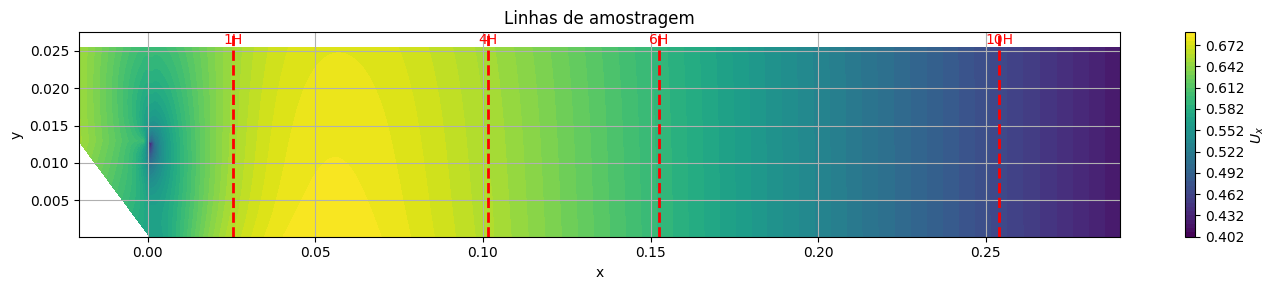

In [111]:
df = pd.read_csv(PATH_DATA / "dataset_bfs_2d_grid.csv")
H = 0.0254
x = df["x"].values
y = df["y"].values
Ux = df["Ux"].values
Uy = df["Uy"].values
plt.figure(figsize=(14, 3))

plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max() * 1.08)

for xpos in [1, 4, 6, 10]:
    x_line = xpos * H
    plt.axvline(x=x_line, color="red", linestyle="--", linewidth=2)
    plt.text(x_line, y.max()*1.02, f"{xpos}H", ha="center", color="red")
plt.tricontourf(x, y, Ux, levels=50)
plt.colorbar(label=r"$U_x$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linhas de amostragem")
plt.grid(True)

plt.gca().set_aspect("auto")   # importante
plt.tight_layout()
plt.show()

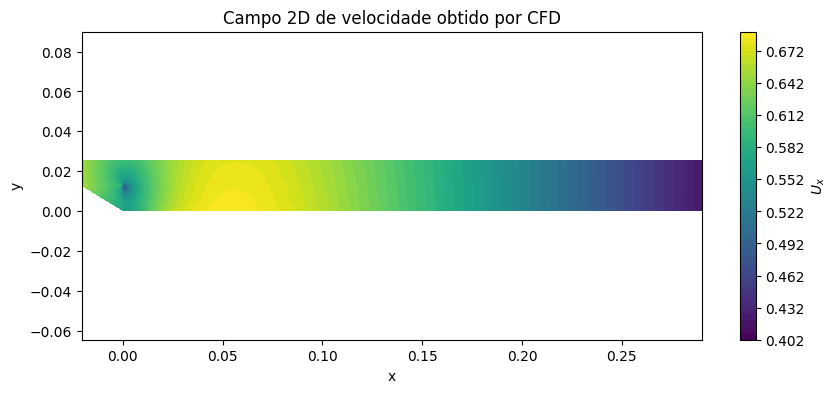

In [106]:
df = pd.read_csv(PATH_DATA / "dataset_bfs_2d_grid.csv")
H = 0.0127
x = df["x"].values
y = df["y"].values
Ux = df["Ux"].values
Uy = df["Uy"].values

U_mag = np.sqrt(Ux**2 + Uy**2)

plt.figure(figsize=(10, 4))
plt.tricontourf(x, y, Ux, levels=50)
plt.colorbar(label=r"$U_x$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo 2D de velocidade obtido por CFD")
plt.axis("equal")
plt.show()

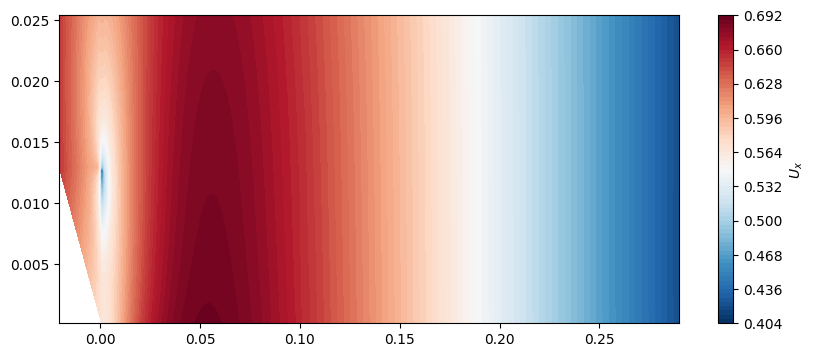

In [96]:
plt.figure(figsize=(10, 4))
plt.tricontourf(
    x,
    y,
    Ux,
    levels=80,
    cmap="RdBu_r"
)
plt.colorbar(label=r"$U_x$")

# Erro de modelagem (EDO X CFD)

In [79]:
def solve_mdf_edo(N, H, C, u_cfd_norm, eta_cfd, resultados):
    eta = np.linspace(0, 1, N)
    dy_eta = eta[1] - eta[0]

    print("Malha dy_eta:", dy_eta)
    print("Size da malha y:", eta.size)
    
    Aw = np.zeros(N)
    Ae = np.zeros(N)
    Ap = np.zeros(N)
    S = C * H**2 * np.ones_like(eta)

    for i in range(1, N-1):
        Aw[i] = 1/dy_eta**2
        Ae[i] = 1/dy_eta**2
        Ap[i] = -2/dy_eta**2

    Ap[0] = 1.0
    S[0] = 0.0

    Ap[N-1] = 1.0
    S[-1] = 0.0

    A = np.zeros((N, N))

    for i in range(1, N-1):
        A[i, i-1] = Aw[i]
        A[i, i] = Ap[i]
        A[i, i+1] = Ae[i]

    A[0, 0] = Ap[0]
    A[N-1, N-1] = Ap[N-1]

    e = np.zeros(N)
    b = np.copy(S)

    for i in range(1, N):
        e[i] = A[i, i-1] / A[i-1, i-1]
        A[i, i] = A[i, i] - e[i] * A[i-1, i]
        b[i] = b[i] - e[i] * b[i-1]
        A[i, i-1] = 0.0

    u_mdf = np.zeros(N)
    u_mdf[N-1] = b[N-1] / A[N-1, N-1]

    for i in range(N-2, -1, -1):
        u_mdf[i] = (b[i] - A[i, i+1] * u_mdf[i+1]) / A[i, i]

    u_mdf_norm = u_mdf / np.max(np.abs(u_mdf))

    u_cfd_interp = np.interp(eta, eta_cfd, u_cfd_norm)

    erro = u_mdf_norm - u_cfd_interp

    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro**2))
    l2_rel = np.linalg.norm(erro) / np.linalg.norm(u_cfd_interp)

    resultados.append([N, dy_eta, mae, rmse, l2_rel])

    return eta, u_mdf_norm, u_cfd_interp, resultados

Processando perfil: dataset_bfs_2d_x_by_h_01
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


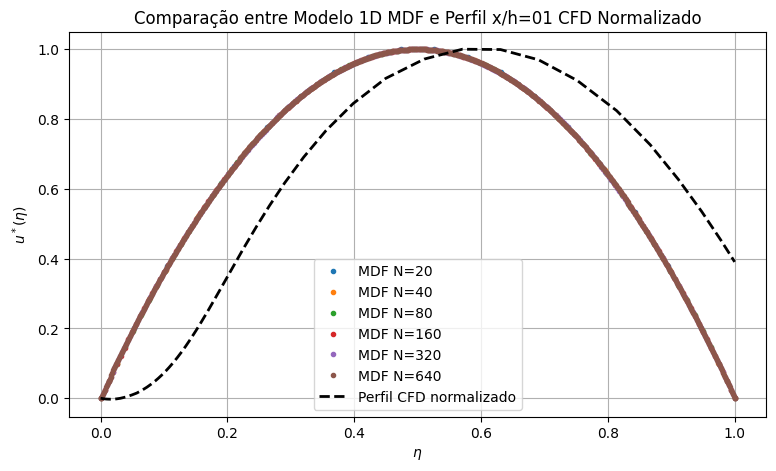

N=  20 | h=5.2632e-02 | MAE=1.8091e-01 | RMSE=2.1313e-01 | L2=2.9843e-01
N=  40 | h=2.5641e-02 | MAE=1.8061e-01 | RMSE=2.1073e-01 | L2=2.9170e-01
N=  80 | h=1.2658e-02 | MAE=1.8045e-01 | RMSE=2.0959e-01 | L2=2.8851e-01
N= 160 | h=6.2893e-03 | MAE=1.8036e-01 | RMSE=2.0907e-01 | L2=2.8702e-01
N= 320 | h=3.1348e-03 | MAE=1.8032e-01 | RMSE=2.0881e-01 | L2=2.8628e-01
N= 640 | h=1.5649e-03 | MAE=1.8030e-01 | RMSE=2.0869e-01 | L2=2.8592e-01


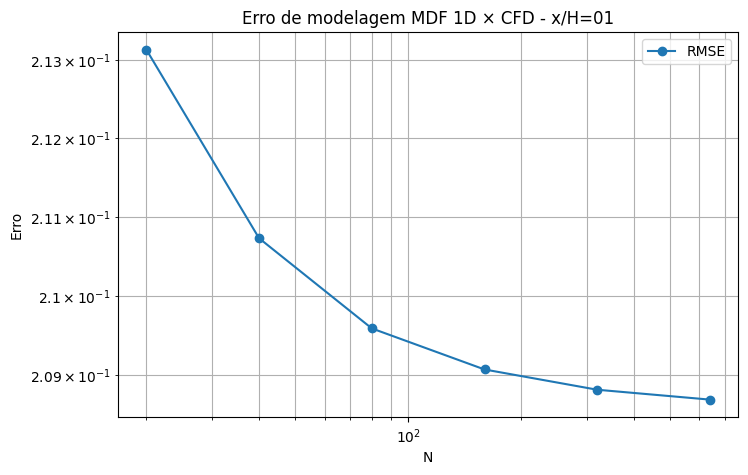

Processando perfil: dataset_bfs_2d_x_by_h_04
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


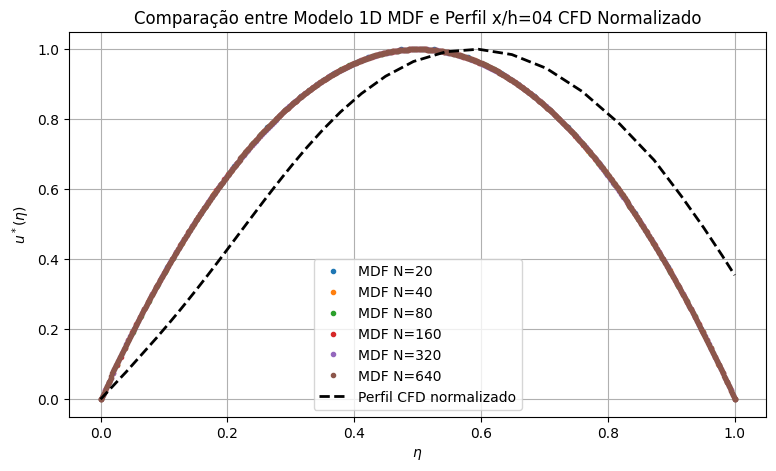

N=  20 | h=5.2632e-02 | MAE=1.4597e-01 | RMSE=1.7317e-01 | L2=2.4228e-01
N=  40 | h=2.5641e-02 | MAE=1.4511e-01 | RMSE=1.7026e-01 | L2=2.3530e-01
N=  80 | h=1.2658e-02 | MAE=1.4467e-01 | RMSE=1.6882e-01 | L2=2.3198e-01
N= 160 | h=6.2893e-03 | MAE=1.4447e-01 | RMSE=1.6813e-01 | L2=2.3040e-01
N= 320 | h=3.1348e-03 | MAE=1.4437e-01 | RMSE=1.6780e-01 | L2=2.2962e-01
N= 640 | h=1.5649e-03 | MAE=1.4431e-01 | RMSE=1.6764e-01 | L2=2.2924e-01


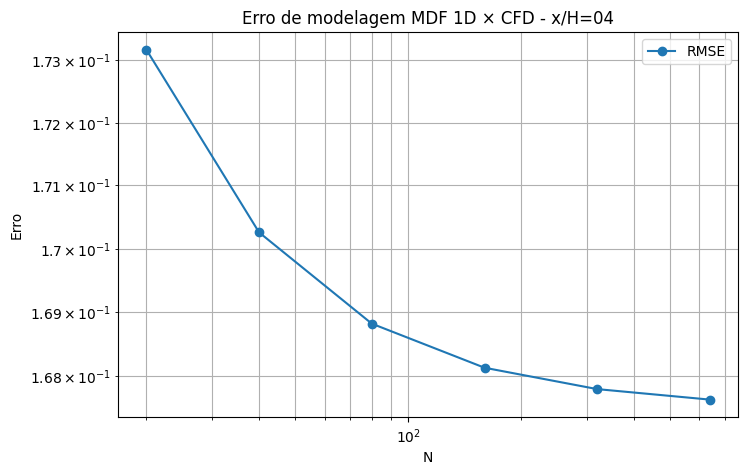

Processando perfil: dataset_bfs_2d_x_by_h_06
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


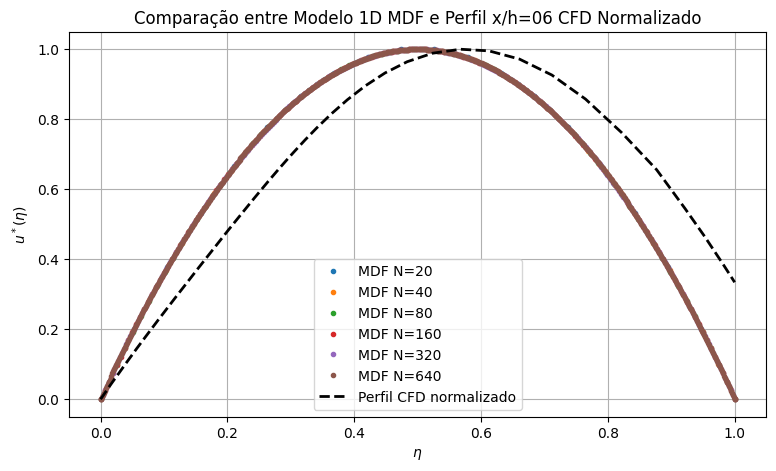

N=  20 | h=5.2632e-02 | MAE=1.2485e-01 | RMSE=1.5133e-01 | L2=2.1033e-01
N=  40 | h=2.5641e-02 | MAE=1.2379e-01 | RMSE=1.4811e-01 | L2=2.0334e-01
N=  80 | h=1.2658e-02 | MAE=1.2316e-01 | RMSE=1.4647e-01 | L2=1.9994e-01
N= 160 | h=6.2893e-03 | MAE=1.2287e-01 | RMSE=1.4569e-01 | L2=1.9831e-01
N= 320 | h=3.1348e-03 | MAE=1.2273e-01 | RMSE=1.4531e-01 | L2=1.9751e-01
N= 640 | h=1.5649e-03 | MAE=1.2266e-01 | RMSE=1.4512e-01 | L2=1.9712e-01


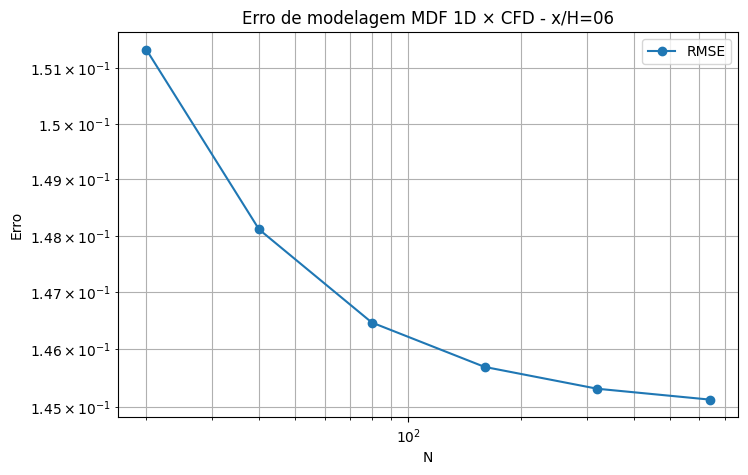

Processando perfil: dataset_bfs_2d_x_by_h_10
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


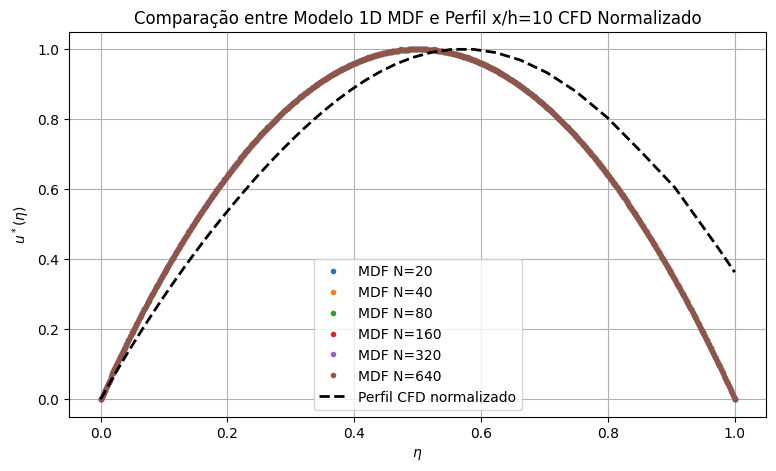

N=  20 | h=5.2632e-02 | MAE=1.1208e-01 | RMSE=1.4637e-01 | L2=1.9939e-01
N=  40 | h=2.5641e-02 | MAE=1.0994e-01 | RMSE=1.4186e-01 | L2=1.9099e-01
N=  80 | h=1.2658e-02 | MAE=1.0901e-01 | RMSE=1.3966e-01 | L2=1.8696e-01
N= 160 | h=6.2893e-03 | MAE=1.0854e-01 | RMSE=1.3858e-01 | L2=1.8499e-01
N= 320 | h=3.1348e-03 | MAE=1.0830e-01 | RMSE=1.3804e-01 | L2=1.8401e-01
N= 640 | h=1.5649e-03 | MAE=1.0819e-01 | RMSE=1.3777e-01 | L2=1.8353e-01


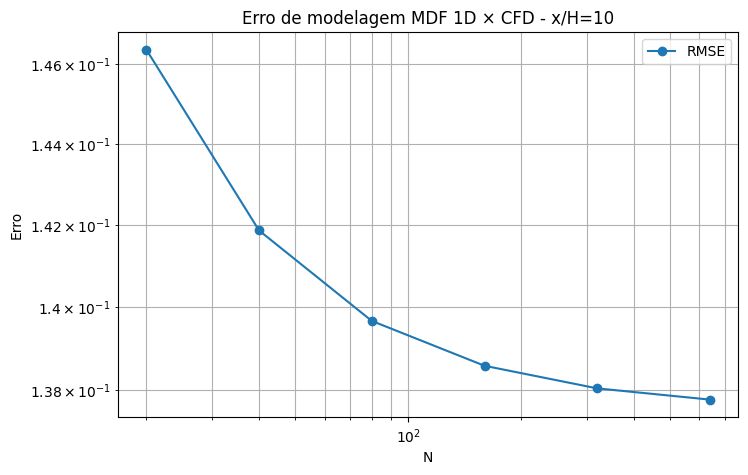

In [83]:
profiles = ["dataset_bfs_2d_x_by_h_01","dataset_bfs_2d_x_by_h_04", "dataset_bfs_2d_x_by_h_06", "dataset_bfs_2d_x_by_h_10"]
for profile_name in profiles:
    print(f"Processando perfil: {profile_name}")
    # Parâmetros do problema
    C = -1.0
    Ns = [20, 40, 80, 160, 320, 640]
    resultados = []

    # Dados CFD
    df_cfd = pd.read_csv(PATH_DATA / f"{profile_name}.csv")
    y_cfd = df_cfd["y"].values
    u_cfd = df_cfd["Ux"].values

    # ordenar por y
    idx = np.argsort(y_cfd)
    y_cfd = y_cfd[idx]
    u_cfd = u_cfd[idx]

    H = y_cfd.max() - y_cfd.min()

    # eta do CFD
    eta_cfd = (y_cfd - y_cfd.min()) / H

    # normalizar CFD
    u_cfd_norm = u_cfd / np.max(np.abs(u_cfd))

    plt.figure(figsize=(9, 5))

    for N in Ns:
        y_eta, u_mdf, u_ref, resultados = solve_mdf_edo(N, H, C, u_cfd_norm, eta_cfd, resultados)
        plt.plot(y_eta, u_mdf, "o", markersize=3, label=f"MDF N={N}")

    # CFD em malha fina
    eta_fino = np.linspace(0, 1, 1000)
    u_cfd_fino = np.interp(eta_fino, eta_cfd, u_cfd_norm)

    plt.plot(
        eta_fino,
        u_cfd_fino,
        "k--",
        linewidth=2,
        label="Perfil CFD normalizado"
    )

    plt.xlabel(r"$\eta$")
    plt.ylabel(r"$u^*(\eta)$")
    plt.title(f"Comparação entre Modelo 1D MDF e Perfil x/h={profile_name.split('_')[-1]} CFD Normalizado")
    plt.grid(True)
    plt.legend()
    plt.show()

    for r in resultados:
        print(
            f"N={r[0]:4d} | h={r[1]:.4e} | "
            f"MAE={r[2]:.4e} | RMSE={r[3]:.4e} | L2={r[4]:.4e}"
        )

    resultados = np.array(resultados)

    plt.figure(figsize=(8, 5))
    plt.loglog(resultados[:, 0], resultados[:, 3], "o-", label="RMSE")
    plt.xlabel("N")
    plt.ylabel("Erro")
    plt.title(f"Erro de modelagem MDF 1D × CFD - x/H={profile_name.split('_')[-1]}")
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

## Insights
O refinamento da malha reduz pouco o erro MDF–CFD, indicando que a principal discrepância decorre das hipóteses do modelo 1D. Além disso, observa-se redução progressiva do erro para maiores valores de x/H, sugerindo que o modelo simplificado se torna mais representativo em regiões mais afastadas do degrau.

Isso indica que o erro diminui conforme o perfil é extraído mais distante do degrau. Essa tendência é fisicamente esperada: longe da recirculação, o escoamento tende a ficar mais próximo de um perfil desenvolvido, então o modelo 1D parabólico representa melhor o CFD.

Também está correto o erro reduzir pouco quando N aumenta. Isso mostra que o erro dominante não é mais de discretização, mas de modelagem física.